In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
def prepare_data(cubes, labels):
    X_list = []
    y_list = []
    for cube_file, label_cube_file in zip(cubes, labels):
        cube = np.load(cube_file)
        label_cube = np.load(label_cube_file) 
        h, w, b = cube.shape
        X_flat = cube.reshape(-1, b)
        y_flat = label_cube.reshape(-1)
        
        mask = y_flat != 0
        X_list.append(X_flat[mask])
        y_list.append(y_flat[mask])
        
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return X, y

In [3]:
label_map = {1: 'Healthy tissue', 2: 'Tumor tissue', 3: 'Blood vessels', 4: 'Dura mater'}

In [4]:
def plot_tsne(X_tsne, y_tsne):
    plt.figure(figsize=(8,6))
    scatter = sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=[label_map[val] for val in y_tsne], hue_order=['Healthy tissue', 'Tumor tissue', 'Blood vessels', 'Dura mater'], palette=['green','red','blue','purple'], s=5, alpha=0.6)
    plt.legend(['Healthy tissue','Tumor tissue','Blood vessels','Dura mater'],title='Class', markerscale=3, loc='upper right')

    scatter.set_xlabel("t-SNE component 1 (a.u.)")
    scatter.set_ylabel("t-SNE component 2 (a.u.)")

    plt.show()

## SLIMBRAIN

In [5]:
folder_cubi_sb = '../datasets/Madrid/hsi/'
folder_labels_sb = '../datasets/Madrid/gt/'

files_cubi_sb = sorted([folder_cubi_sb+f for f in os.listdir(folder_cubi_sb) if f.endswith('.npy')])
files_labels_sb = sorted([folder_labels_sb+f for f in os.listdir(folder_labels_sb) if f.endswith('.npy')])

In [6]:
X1, y1 = prepare_data(files_cubi_sb, files_labels_sb)

In [7]:
X1_sub, _, y1_sub, _ = train_test_split(
    X1, y1,
    train_size=0.1,
    stratify=y1,
    random_state=42
)

In [8]:
print(X1_sub.shape, y1_sub.shape)
print(X1.shape, y1.shape)

(33153, 25) (33153,)
(331539, 25) (331539,)


In [9]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    n_iter=1000,
    random_state=42
)

X1_tsne = tsne.fit_transform(X1_sub, y1_sub)

c:\Users\windows\.conda\envs\plots\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


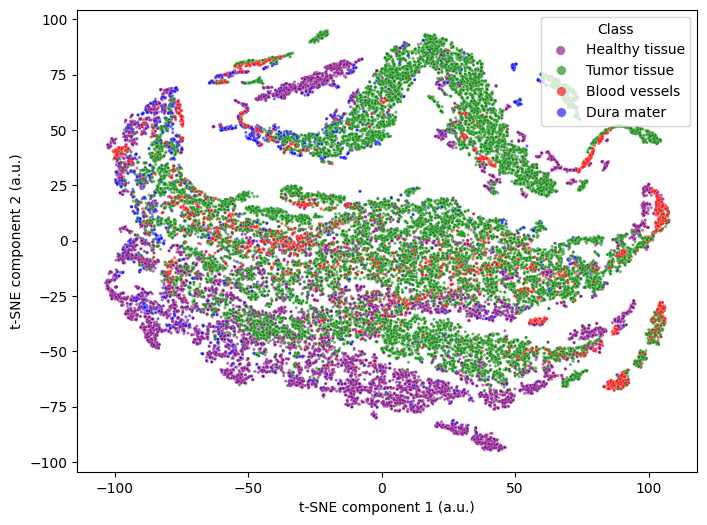

In [10]:
plot_tsne(X1_tsne, y1_sub)

## HELICoiD

In [11]:
folder_cubi_lp = '../datasets/LP/hsi/'
folder_labels_lp = '../datasets/LP/gt/'

files_cubi_lp = sorted([folder_cubi_lp+f for f in os.listdir(folder_cubi_lp) if f.endswith('.npy')])
files_labels_lp = sorted([folder_labels_lp+f for f in os.listdir(folder_labels_lp) if f.endswith('.npy')])

In [12]:
X2, y2 = prepare_data(files_cubi_lp, files_labels_lp)

In [13]:
X2_sub, _, y2_sub, _ = train_test_split(
    X2, y2,
    train_size=0.1,
    stratify=y2,
    random_state=42
)

In [14]:
print(X2.shape, y2.shape)
print(X2_sub.shape, y2_sub.shape)

(1020717, 128) (1020717,)
(102071, 128) (102071,)


In [15]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    n_iter=1000,
    random_state=42
)

X2_tsne = tsne.fit_transform(X2_sub, y2)

c:\Users\windows\.conda\envs\plots\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


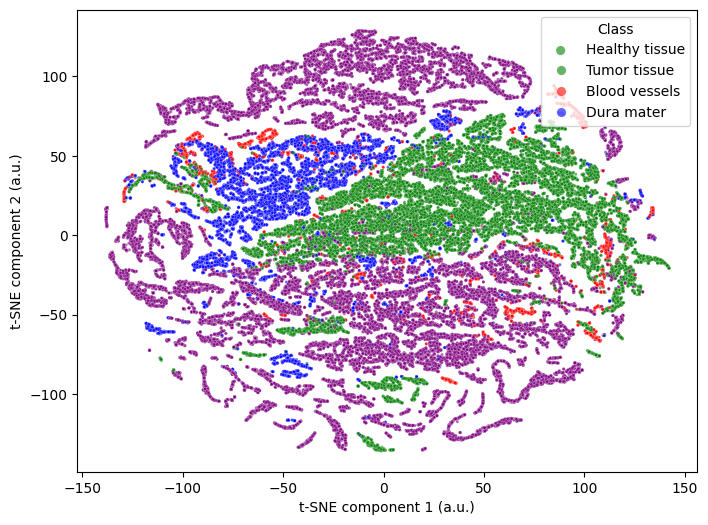

In [16]:
plot_tsne(X2_tsne, y2_sub)

## Combination

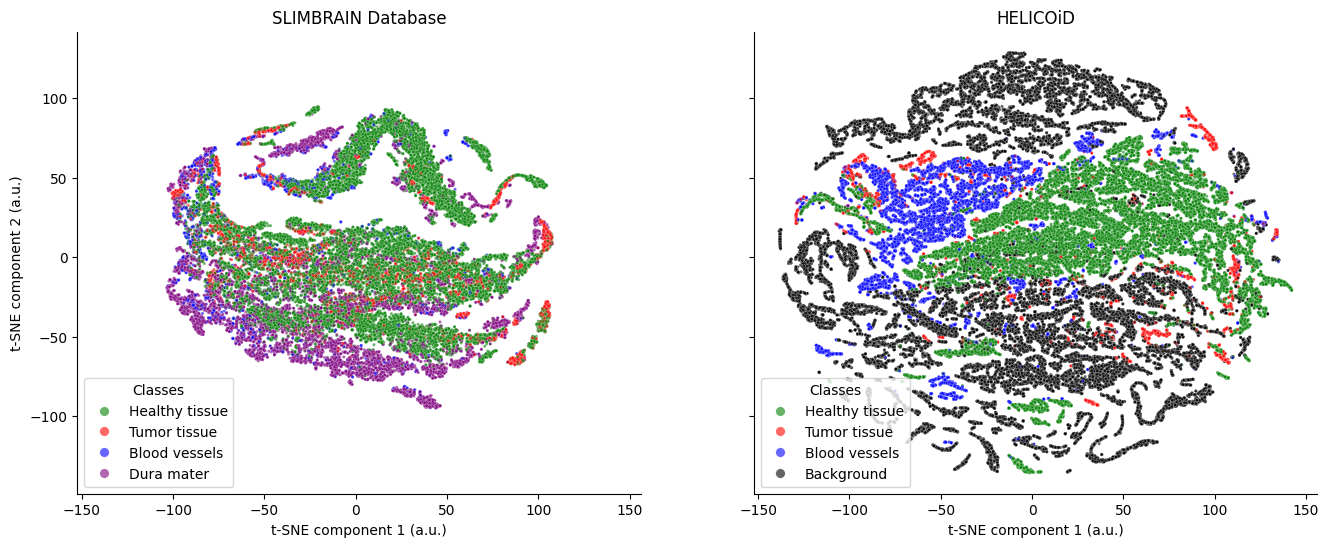

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

scatter1 = sns.scatterplot(
    ax=axes[0],
    x=X1_tsne[:, 0],
    y=X1_tsne[:, 1],
    hue=[label_map[val] for val in y1_sub],
    hue_order=['Healthy tissue', 'Tumor tissue', 'Blood vessels', 'Dura mater'],
    palette=['green', 'red', 'blue', 'purple'],
    s=5,
    alpha=0.6
)
axes[0].set_title("SLIMBRAIN Database")
axes[0].legend(title="Classes", markerscale=3, loc='lower left')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
scatter1.set_xlabel("t-SNE component 1 (a.u.)")
scatter1.set_ylabel("t-SNE component 2 (a.u.)")

scatter2 = sns.scatterplot(
    ax=axes[1],
    x=X2_tsne[:, 0],
    y=X2_tsne[:, 1],
    hue=[label_map[val] for val in y2_sub],
    hue_order=['Healthy tissue', 'Tumor tissue', 'Blood vessels', 'Background'],
    palette=['green', 'red', 'blue', 'black'],
    s=5,
    alpha=0.6
)
axes[1].set_title("HELICOiD")
axes[1].legend(title="Classes", markerscale=3, loc='lower left')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
scatter2.set_xlabel("t-SNE component 1 (a.u.)")
scatter2.set_ylabel("t-SNE component 2 (a.u.)")


plt.savefig('t_sne_separability.png', dpi=1200, bbox_inches='tight', transparent=True)
plt.show()